# **🚜 Predicting the Sale Price of Bulldozers using Machine Learning**

In this notebook, we're going to go through an example of machine learning project with the goal of predicting the sale price of bulldozers.

- **Inputs**: Bulldozer characteristics such as make year, base model, model series, state of sale (e.g. which US state was it sold in), drive system and more.
- **Outputs**: Bulldozer sale price (in USD).

---

Since we're trying to predict a number, this kind of problem is known as a **regression problem**.


And since we're going to predicting results with a time component (predicting future sales based on past sales), this is also known as a **time series** or **forecasting problem**.


- The [Data](https://www.dropbox.com/scl/fi/pjrulzwpa2osmtcl34j5c/dog-breed-identification.zip?rlkey=illavzwa19vysrolwpgqov86a&e=1&dl=0) is taken from [Kaggle Bluebook for Buldozers competition](https://www.kaggle.com/competitions/bluebook-for-bulldozers/overview)

---

# **Overview**

Since we already have a dataset, we'll approach the problem with the following machine learning modelling framework.

<center>

![6 Step Machine Learning Modelling Framework](./assets/images/6%20Step%20Machine%20Learning%20Modelling%20Framework.png)

</center>

---

<center>

> 6 Step Machine Learning Modelling Framework

</center>


**Thought Process:**

![6 Step ml plan](./assets/images/6-step-ml-framework.png)

## **1. Problem Defination:**

> How well we can predict the future sales price of a bulldozer, given it's characteristic and previous examples of how much similar bulldozers have been sold for? 

## **2. Data**

The data is downloaded from Kaggle [Bluebook for Bulldozers Compitition](https://www.kaggle.com/competitions/bluebook-for-bulldozers/overview).


**There are 3 main datasets:**

- **Train.csv** - Historical bulldozer sales examples up to 2011 (close to 400,000 examples with 50+ different attributes, including SalePrice which is the target variable).
  
- **Valid.csv** - Historical bulldozer sales examples from January 1 2012 to April 30 2012 (close to 12,000 examples with the same attributes as Train.csv).
  
- **Test.csv** - Historical bulldozer sales examples from May 1 2012 to November 2012 (close to 12,000 examples but missing the SalePrice attribute, as this is what we'll be trying to predict).

## **3. Evaluation**

The evaluation metric for this competition is the **`RMSLE`** (**root mean squared log error**) between the actual and predicted auction prices.

For more evaluation of this project check: [Here](www.kaggle.com/competitions/bluebook-for-bulldozers/overview/evaluation)


> **Note:** The goal for most regression evaluation metrics is to minimize the error.
>For example, our goal for this project is to build a machine learning model which minimises **`RMSLE`**.

## **4. Features**

Kaggle provides a data dictionary for all of the features of the dataset. You can view this data:
- [URL](https://www.kaggle.com/competitions/bluebook-for-bulldozers/data)
- [Locally for me](./dataset/Data%20Dictionary.xlsx)

## **Importing the data and preparing it for modelling**

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Import training and validation sets

df = pd.read_csv("./dataset/TrainAndValid.csv",
                 low_memory=False)

# Use low_memory=False so pandas
# reads the CSV more reliably and avoids
# guessing column types in chunks.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   str    
 9   saledate                  412698 non-null  str    
 10  fiModelDesc               412698 non-null  str    
 11  fiBaseModel               412698 non-null  str    
 12  fiSecondaryDesc           271971 non-null  str    
 13  fiModelSeries             58667 non-null   str    
 14 

In [4]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

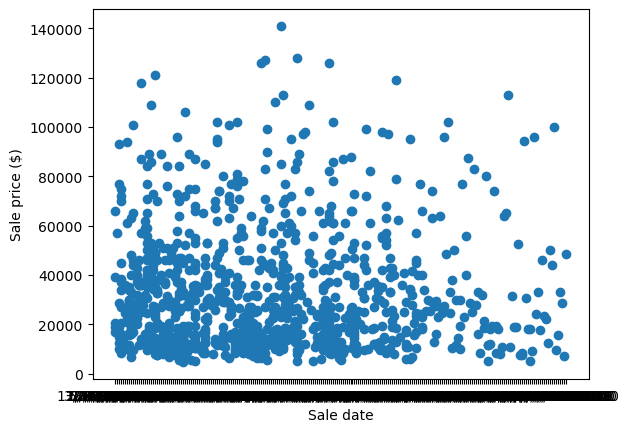

In [5]:
fig, ax = plt.subplots()
ax.scatter(df["saledate"][:1000], df["SalePrice"][:1000])
ax.set_xlabel("Sale date")
ax.set_ylabel("Sale price ($)");

In [6]:
df.saledate[:1000]

0      11/16/2006 0:00
1       3/26/2004 0:00
2       2/26/2004 0:00
3       5/19/2011 0:00
4       7/23/2009 0:00
            ...       
995     7/16/2009 0:00
996     6/14/2007 0:00
997     9/22/2005 0:00
998     7/28/2005 0:00
999     6/16/2011 0:00
Name: saledate, Length: 1000, dtype: str

In [7]:
df["saledate"].dtypes

<StringDtype(storage='python', na_value=nan)>

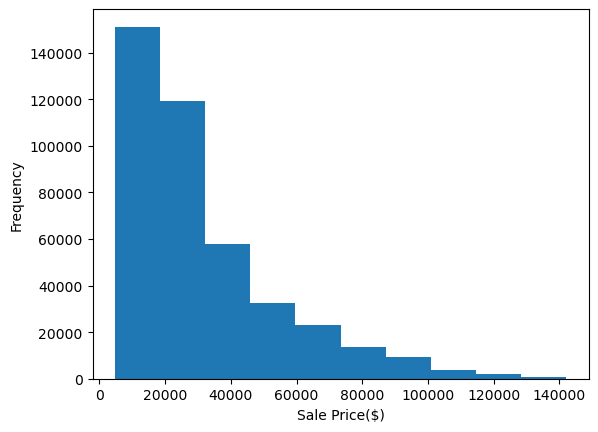

In [8]:
df.SalePrice.plot.hist()
plt.xlabel("Sale Price($)");

### **Parsing Dates**

When we are working with **time series data**, we want to enrich the time and date component as much as possible.

We can do that by telling the pandas which of our columns has dates in it using the **`parse_dates`** parameter.

- When pandas reads a CSV, date columns load as plain **strings** by default.  
`parse_dates=["saledate"]` converts them into real **DateTime objects** — so we can do math and extract info from them.

In [9]:
# Import the data again but this tiime parse dates
df = pd.read_csv("./dataset/TrainAndValid.csv",
                 low_memory=False,
                 parse_dates=["saledate"])

`parse_dates=["saledate"]` tells pandas:

> "When you load this column, don't treat it as text — convert it into a proper DateTime object automatically."

- Without it → `saledate` is dtype `object` (string)
With it → `saledate` is dtype `datetime64` (real date)

In [10]:
df.saledate.dtype

# dtype('<M8[us]') means the column is a NumPy
# datetime type (date + time), stored with
# microsecond (us) precision

dtype('<M8[us]')

In [11]:
df.saledate[:1000]

0     2006-11-16
1     2004-03-26
2     2004-02-26
3     2011-05-19
4     2009-07-23
         ...    
995   2009-07-16
996   2007-06-14
997   2005-09-22
998   2005-07-28
999   2011-06-16
Name: saledate, Length: 1000, dtype: datetime64[us]

In [12]:
np.dtype('<M8[us]') == np.dtype('<datetime64[us]')

True

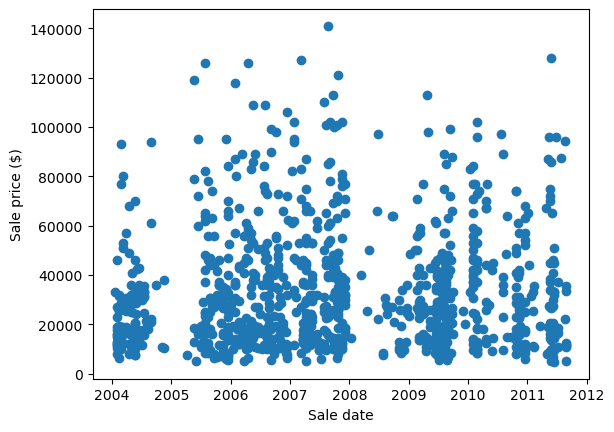

In [13]:
fig, ax = plt.subplots()
ax.scatter(df['saledate'][:1000], df['SalePrice'][:1000])
ax.set_xlabel("Sale date")
ax.set_ylabel("Sale price ($)");

In [14]:
pd.set_option("display.max_columns", None) # Display all the columns

In [15]:
df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelDescriptor,ProductSize,fiProductClassDesc,state,ProductGroup,ProductGroupDesc,Drive_System,Enclosure,Forks,Pad_Type,Ride_Control,Stick,Transmission,Turbocharged,Blade_Extension,Blade_Width,Enclosure_Type,Engine_Horsepower,Hydraulics,Pushblock,Ripper,Scarifier,Tip_Control,Tire_Size,Coupler,Coupler_System,Grouser_Tracks,Hydraulics_Flow,Track_Type,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,2006-11-16,521D,521,D,NaN,NaN,NaN,Wheel Loader - 110.0 to 120.0 Horsepower,Alabama,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,2004-03-26,950FII,950,F,II,NaN,Medium,Wheel Loader - 150.0 to 175.0 Horsepower,North Carolina,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2004-02-26,226,226,NaN,NaN,NaN,NaN,Skid Steer Loader - 1351.0 to 1601.0 Lb Operat...,New York,SSL,Skid Steer Loaders,NaN,OROPS,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,None or Unspecified,None or Unspecified,None or Unspecified,Standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,2011-05-19,PC120-6E,PC120,NaN,-6E,NaN,Small,"Hydraulic Excavator, Track - 12.0 to 14.0 Metr...",Texas,TEX,Track Excavators,NaN,EROPS w AC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,2009-07-23,S175,S175,NaN,NaN,NaN,NaN,Skid Steer Loader - 1601.0 to 1751.0 Lb Operat...,New York,SSL,Skid Steer Loaders,NaN,EROPS,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,None or Unspecified,None or Unspecified,None or Unspecified,Standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.head().T

,0,1,2,3,4
SalesID,1139246,1139248,1139249,1139251,1139253
SalePrice,66000.0,57000.0,10000.0,38500.0,11000.0
MachineID,999089,117657,434808,1026470,1057373
ModelID,3157,77,7009,332,17311
datasource,121,121,121,121,121
auctioneerID,3.0,3.0,3.0,3.0,3.0
YearMade,2004,1996,2001,2001,2007
MachineHoursCurrentMeter,68.0,4640.0,2838.0,3486.0,722.0
UsageBand,Low,Low,High,High,Medium
saledate,2006-11-16 00:00:00,2004-03-26 00:00:00,2004-02-26 00:00:00,2011-05-19 00:00:00,2009-07-23 00:00:00


In [17]:
df.saledate.head(20)

0    2006-11-16
1    2004-03-26
2    2004-02-26
3    2011-05-19
4    2009-07-23
5    2008-12-18
6    2004-08-26
7    2005-11-17
8    2009-08-27
9    2007-08-09
10   2008-08-21
11   2006-08-24
12   2005-10-20
13   2006-01-26
14   2006-01-03
15   2006-11-16
16   2007-06-14
17   2010-01-28
18   2006-03-09
19   2005-11-17
Name: saledate, dtype: datetime64[us]

### **Sort DataFrame by `saledate`**

When working with time series data, it's good idea to sort it by date 

In [18]:
# Sort DataFrame in date order
df.sort_values(by=['saledate'],
               inplace=True,
               ascending=True)
df.saledate.head(20)

205615   1989-01-17
274835   1989-01-31
141296   1989-01-31
212552   1989-01-31
62755    1989-01-31
54653    1989-01-31
81383    1989-01-31
204924   1989-01-31
135376   1989-01-31
113390   1989-01-31
113394   1989-01-31
116419   1989-01-31
32138    1989-01-31
127610   1989-01-31
76171    1989-01-31
127000   1989-01-31
128130   1989-01-31
127626   1989-01-31
55455    1989-01-31
55454    1989-01-31
Name: saledate, dtype: datetime64[us]

### **Make a copy of original DataFrame**

We make a copy of the original Dataframe so when we manipulate the copy, we've still got our original data.

In [19]:
# Make a copy
df_tmp = df.copy()

In [20]:
df_tmp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


### **What is Feature Engineering?**
Transforming raw data into more useful numeric inputs for the model.  
A model can't learn from `"2011-11-16"` — but it *can* learn from `year=2011, month=11, day=16`.

---

### **What is Data Enrichment?**
A type of feature engineering — unpacking **one column** into **many useful columns**.

```python
df["sale_year"]       = df["saledate"].dt.year
df["sale_month"]      = df["saledate"].dt.month
df["sale_day"]        = df["saledate"].dt.day
df["sale_dayofweek"]  = df["saledate"].dt.dayofweek   # Mon=0, Sun=6
df["sale_quarter"]    = df["saledate"].dt.quarter
```

---

### Why does this matter for Bulldozers?
`saledate` contains hidden signals:
- construction season, 
- market cycles, 
- auction patterns.  
Enriching it lets the model **learn from time** instead of ignoring it.

> **Rule of thumb:** enrich DateTime columns as much as possible before modeling.

---

### **Add Datetime parameters for `saledate` column**

In [21]:
df_tmp["saleYear"] = df_tmp['saledate'].dt.year
df_tmp["saleMonth"] = df_tmp['saledate'].dt.month
df_tmp["saleDay"] = df_tmp['saledate'].dt.day
df_tmp['saleDayOfWeek'] = df_tmp["saledate"].dt.dayofweek
df_tmp['saleDayOfYear'] = df_tmp["saledate"].dt.dayofyear

In [22]:
df_tmp[['SalePrice', "saleYear", "saleMonth", "saleDay", "saleDayOfWeek", "saleDayOfYear"]].head()

,SalePrice,saleYear,saleMonth,saleDay,saleDayOfWeek,saleDayOfYear
205615,9500.0,1989,1,17,1,17
274835,14000.0,1989,1,31,1,31
141296,50000.0,1989,1,31,1,31
212552,16000.0,1989,1,31,1,31
62755,22000.0,1989,1,31,1,31


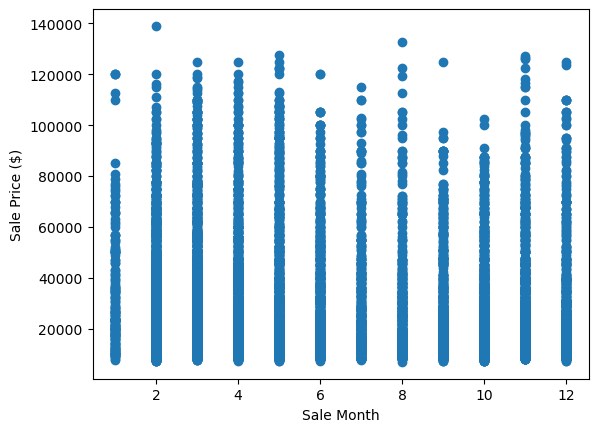

In [23]:
# View 10,000 samples SalePrice against saleMonth
fig, ax = plt.subplots()
ax.scatter(df_tmp['saleMonth'][:10000],
           df_tmp['SalePrice'][:10000])
ax.set_xlabel("Sale Month")
ax.set_ylabel("Sale Price ($)");

Hmm... doesn't look like there's too much conclusive evidence here about which month has the highest sales value.

How about we plot the median sale price of each month?

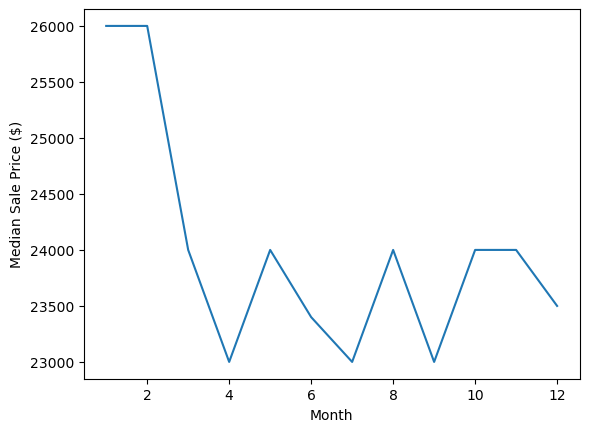

In [24]:
# Group DataFrame by saleMonth and find the median SalePrice
df_tmp.groupby(["saleMonth"])["SalePrice"].median().plot()
plt.xlabel("Month")
plt.ylabel("Median Sale Price ($)");

Ohhh it looks like the median sale prices of January and February (months 1 and 2) are quite a bit higher than the other months of the year.

Could this be because of New Year budget spending?

Perhaps... but this would take a bit more investigation.

In the meantime, there are many other values we could look further into.

In [25]:
df_tmp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


In [26]:
# Now we have enriched our DataFrame with datetime features we can remove 'saledate'
df_tmp.drop("saledate", axis=1, inplace=True)

In [27]:
# Check the Values of different columns
df_tmp['state'].value_counts()

state
Florida           67320
Texas             53110
California        29761
Washington        16222
Georgia           14633
Maryland          13322
Mississippi       13240
Ohio              12369
Illinois          11540
Colorado          11529
New Jersey        11156
North Carolina    10636
Tennessee         10298
Alabama           10292
Pennsylvania      10234
South Carolina     9951
Arizona            9364
New York           8639
Connecticut        8276
Minnesota          7885
Missouri           7178
Nevada             6932
Louisiana          6627
Kentucky           5351
Maine              5096
Indiana            4124
Arkansas           3933
New Mexico         3631
Utah               3046
Unspecified        2801
Wisconsin          2745
New Hampshire      2738
Virginia           2353
Idaho              2025
Oregon             1911
Michigan           1831
Wyoming            1672
Montana            1336
Iowa               1336
Oklahoma           1326
Nebraska            866
West Virgi

Woah! Looks like Flordia sells a fair few bulldozers.

How about we go even further and group our samples by state and then find the median SalePrice per state?

We also compare this to the median SalePrice for all samples.

In [28]:
df_tmp.groupby(['state'])["SalePrice"].median()

state
Alabama           28000.0
Alaska            26000.0
Arizona           23000.0
Arkansas          22500.0
California        22500.0
Colorado          25000.0
Connecticut       23500.0
Delaware          23000.0
Florida           27000.0
Georgia           24000.0
Hawaii            26000.0
Idaho             21000.0
Illinois          22500.0
Indiana           19000.0
Iowa              24000.0
Kansas            20000.0
Kentucky          22000.0
Louisiana         23500.0
Maine             19500.0
Maryland          22000.0
Massachusetts     23000.0
Michigan          22000.0
Minnesota         19500.0
Mississippi       25000.0
Missouri          22000.0
Montana           24000.0
Nebraska          24250.0
Nevada            27000.0
New Hampshire     23000.0
New Jersey        24500.0
New Mexico        26000.0
New York          20000.0
North Carolina    25000.0
North Dakota      29750.0
Ohio              22000.0
Oklahoma          24000.0
Oregon            23000.0
Pennsylvania      19000.0
Puerto

In [29]:
df_tmp['SalePrice'].median()

np.float64(24000.0)

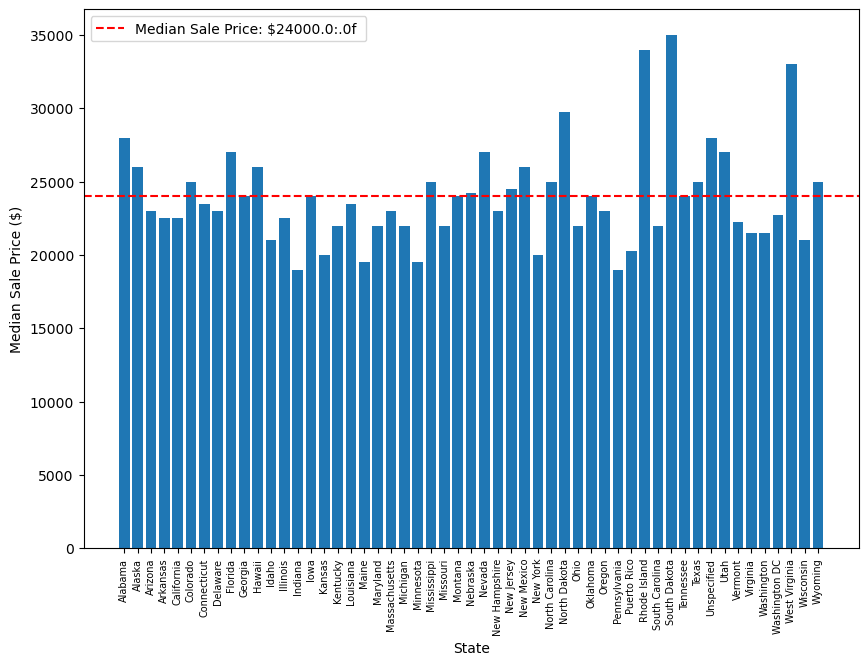

In [30]:
# Group the DataFrame by saleMonth and then find the median SalePrice per state as well as whole dataset
median_prices_by_state = df_tmp.groupby(['state'])["SalePrice"].median()
median_sale_price = df_tmp['SalePrice'].median()

# Create a plot comparing median sale price per state to median sale price overall
fig, ax = plt.subplots(figsize=(10,7))
plt.bar(x=median_prices_by_state.index, # Because we're working with a Series, we can use the index(state names) as x values
        height=median_prices_by_state.values)
plt.xlabel("State")
plt.ylabel("Median Sale Price ($)")
plt.xticks(rotation=90, fontsize=7)
plt.axhline(y=median_sale_price,
            color='red',
            linestyle='--',
            label=f"Median Sale Price: ${median_sale_price}:.0f ")
plt.legend();

Now that's a nice looking figure!

Interestingly Florida has the most sales and the median sale price is above the overall median of all other states.

And if you had a bulldozer and were chasing the highest sale price, the data would reveal that perhaps selling in South Dakota would be your best bet.

Perhaps bulldozers are in higher demand in South Dakota because of a building or mining boom?

Answering this would require a bit more research.

But what we're doing here is slowly building up a mental model of our data.

So that if we saw an example in the future, we could compare its values to the ones we've already seen.

In [31]:
df_tmp.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelDescriptor,ProductSize,fiProductClassDesc,state,ProductGroup,ProductGroupDesc,Drive_System,Enclosure,Forks,Pad_Type,Ride_Control,Stick,Transmission,Turbocharged,Blade_Extension,Blade_Width,Enclosure_Type,Engine_Horsepower,Hydraulics,Pushblock,Ripper,Scarifier,Tip_Control,Tire_Size,Coupler,Coupler_System,Grouser_Tracks,Hydraulics_Flow,Track_Type,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayOfWeek,saleDayOfYear
205615,1646770,9500.0,1126363,8434,132,18.0,1974,NaN,NaN,TD20,TD20,NaN,NaN,NaN,Medium,"Track Type Tractor, Dozer - 105.0 to 130.0 Hor...",Texas,TTT,Track Type Tractors,NaN,OROPS,NaN,NaN,NaN,NaN,Direct Drive,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,17,1,17
274835,1821514,14000.0,1194089,10150,132,99.0,1980,NaN,NaN,A66,A66,NaN,NaN,NaN,NaN,Wheel Loader - 120.0 to 135.0 Horsepower,Florida,WL,Wheel Loader,NaN,OROPS,None or Unspecified,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional,1989,1,31,1,31
141296,1505138,50000.0,1473654,4139,132,99.0,1978,NaN,NaN,D7G,D7,G,NaN,NaN,Large,"Track Type Tractor, Dozer - 190.0 to 260.0 Hor...",Florida,TTT,Track Type Tractors,NaN,OROPS,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,31,1,31
212552,1671174,16000.0,1327630,8591,132,99.0,1980,NaN,NaN,A62,A62,NaN,NaN,NaN,NaN,Wheel Loader - Unidentified,Florida,WL,Wheel Loader,NaN,EROPS,None or Unspecified,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional,1989,1,31,1,31
62755,1329056,22000.0,1336053,4089,132,99.0,1984,NaN,NaN,D3B,D3,B,NaN,NaN,NaN,"Track Type Tractor, Dozer - 20.0 to 75.0 Horse...",Florida,TTT,Track Type Tractors,NaN,OROPS,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,Lever,NaN,NaN,1989,1,31,1,31


In [32]:
len(df_tmp)

412698

## **5. Modelling**

We have done enough EDA (we can always do more) but let's start to do some model-driven EDA

>- **Regular EDA**       →  You guess what matters
>- **Model-driven EDA**  →  The model shows you what actually matters → `model.feature_importances_`

---

[Choosing the Right Estimator](./assets/images/sklearn-ml-map.png)

In [33]:
## Let's build a machine learning model
# from sklearn.ensemble import RandomForestRegressor

# X = df_tmp.drop('SalePrice', axis=1)
# y = df_tmp['SalePrice']

# model = RandomForestRegressor(n_jobs=-1,
#                               random_state=42)

# model.fit(X, y)

## → Will Give error since all the data is not in numerical form

In [34]:
df_tmp.info()

<class 'pandas.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   str    
 9   fiModelDesc               412698 non-null  str    
 10  fiBaseModel               412698 non-null  str    
 11  fiSecondaryDesc           271971 non-null  str    
 12  fiModelSeries             58667 non-null   str    
 13  fiModelDescriptor         74816 non-null   str    
 14 

In [35]:
df_tmp["UsageBand"].dtype

<StringDtype(storage='python', na_value=nan)>

In [36]:
df_tmp.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension             386715
Blade_Width         

### **Covert strings into categories**

One way we can turn all of our data into numbers is by converting them into pandas categories.

We can check the different data types compatible with pandas: [Here](https://pandas.pydata.org/docs/reference/arrays.html)

In [37]:
df_tmp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


In [38]:
pd.api.types.is_string_dtype(df_tmp['UsageBand'])

True

In [39]:
df_tmp.items()
# For each column it gives
# the column name (eg. SaleID)
# the column data as a Series (eg. 25000, ...)

<generator object DataFrame.items at 0x0000027C036D1B70>

In [40]:
# Find the columns which contains the string
for label, content in df_tmp.items():
    if pd.api.types.is_string_dtype(content):
        print(label)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [41]:
# If you're wondering what df.items() does, here's an example
random_dict = {"key1": "Hello",
               "key2": "Hola",
               "key3" : "Ola",
               "key4" : "World!!"}

for key, values in random_dict.items():
    print(f"This is a key: {key}")
    print(f"This is a value: {values}")

This is a key: key1
This is a value: Hello
This is a key: key2
This is a value: Hola
This is a key: key3
This is a value: Ola
This is a key: key4
This is a value: World!!


In [42]:
# This will turn all of the string value into category values
for label, content in df_tmp.items():
    if pd.api.types.is_string_dtype(content):
        df_tmp[label] = content.astype("category").cat.as_ordered()

`category` is memory-efficient and model-prep friendly.

`ordered=True` or `.cat.as_ordered` should be used only when order is real and meaningful among categories.
- `UsageBand` is a good candidate if values represent intensity levels like Low, Medium, High.
- `ProductSize` can also be a candidate if values represent increasing machine size.
- `State`, `ProductGroup`, `ModelID`-like labels are usually not naturally ordered.

In [43]:
df_tmp.info()

<class 'pandas.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         74816 non-null

In [44]:
# Shows the list of unique category labels of state
df_tmp['state'].cat.categories

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'Washington DC', 'West Virginia', 'Wisconsin',
       'Wyoming'],
      dtype='str')

In [45]:
df_tmp.state.value_counts()

state
Florida           67320
Texas             53110
California        29761
Washington        16222
Georgia           14633
Maryland          13322
Mississippi       13240
Ohio              12369
Illinois          11540
Colorado          11529
New Jersey        11156
North Carolina    10636
Tennessee         10298
Alabama           10292
Pennsylvania      10234
South Carolina     9951
Arizona            9364
New York           8639
Connecticut        8276
Minnesota          7885
Missouri           7178
Nevada             6932
Louisiana          6627
Kentucky           5351
Maine              5096
Indiana            4124
Arkansas           3933
New Mexico         3631
Utah               3046
Unspecified        2801
Wisconsin          2745
New Hampshire      2738
Virginia           2353
Idaho              2025
Oregon             1911
Michigan           1831
Wyoming            1672
Iowa               1336
Montana            1336
Oklahoma           1326
Nebraska            866
West Virgi

In [46]:
# Shows the integer code for each row based on that category list of states
df_tmp.state.cat.codes

205615    43
274835     8
141296     8
212552     8
62755      8
          ..
410879     4
412476     4
411927     4
407124     4
409203     4
Length: 412698, dtype: int8

**Thanks to pandas categories we now have a way to access all of our data in the form of numbers.**

But we still have a bunch of missing data...

In [47]:
# Check missing data 
df_tmp.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension             386715
Blade_Width         

In [48]:
# Check missing data comapre to whole dataset
df_tmp.isna().sum() / len(df_tmp)

SalesID                     0.000000
SalePrice                   0.000000
MachineID                   0.000000
ModelID                     0.000000
datasource                  0.000000
auctioneerID                0.048791
YearMade                    0.000000
MachineHoursCurrentMeter    0.642586
UsageBand                   0.821492
fiModelDesc                 0.000000
fiBaseModel                 0.000000
fiSecondaryDesc             0.340993
fiModelSeries               0.857845
fiModelDescriptor           0.818715
ProductSize                 0.524851
fiProductClassDesc          0.000000
state                       0.000000
ProductGroup                0.000000
ProductGroupDesc            0.000000
Drive_System                0.740520
Enclosure                   0.000809
Forks                       0.520921
Pad_Type                    0.803498
Ride_Control                0.629928
Stick                       0.803498
Transmission                0.544444
Turbocharged                0.803498
B

### **Save preprocessed data**

In [49]:
# Export current temp dataframe
df_tmp.to_csv("./dataset/MyLocalData/train_temp.csv",
              index=False)

In [50]:
# Import preprocessed data
df_tmp = pd.read_csv("./dataset/MyLocalData/train_temp.csv",
                     low_memory=False)

In [51]:
df_tmp.head().T

,0,1,2,3,4
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


In [52]:
df_tmp.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension             386715
Blade_Width         

## **Fill missing values**

### **Fill numeric missing values first**

In [53]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

SalesID
SalePrice
MachineID
ModelID
datasource
auctioneerID
YearMade
MachineHoursCurrentMeter
saleYear
saleMonth
saleDay
saleDayOfWeek
saleDayOfYear


In [54]:
df_tmp.ModelID

0          8434
1         10150
2          4139
3          8591
4          4089
          ...  
412693     5266
412694    19330
412695    17244
412696     3357
412697     4701
Name: ModelID, Length: 412698, dtype: int64

In [55]:
# Check for which numeric columns have null values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

auctioneerID
MachineHoursCurrentMeter


In [56]:
# Fill numeric rows with the median
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # Add a binary column which tells us if the data was missing or not
            df_tmp[label + "_is_missing"] = pd.isnull(content)
            # Fill missing numeric values with median
            df_tmp[label] = content.fillna(content.median())

In [57]:
# Demostrate how median is more robust than mean 
hundreds = np.full((1000,), 100)
hundreds_billion = np.append(hundreds, 1000000000)

np.mean(hundreds), np.mean(hundreds_billion), np.median(hundreds), np.median(hundreds_billion)

(np.float64(100.0),
 np.float64(999100.8991008991),
 np.float64(100.0),
 np.float64(100.0))

- The **mean** changes easily because it adds up every number, so one huge outlier can ruin the average.

- The **median** stays stable because it only looks at the middle position, ignoring how extreme the values at the ends are.

In [58]:
# Check if there any null numeric values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

In [59]:
# Check to see how many examples were missing
df_tmp.auctioneerID_is_missing.value_counts()

auctioneerID_is_missing
False    392562
True      20136
Name: count, dtype: int64

In [60]:
# Check to see how many examples were missing
df_tmp.MachineHoursCurrentMeter_is_missing.value_counts()

MachineHoursCurrentMeter_is_missing
True     265194
False    147504
Name: count, dtype: int64

In [61]:
df_tmp.isna().sum()

SalesID                                     0
SalePrice                                   0
MachineID                                   0
ModelID                                     0
datasource                                  0
auctioneerID                                0
YearMade                                    0
MachineHoursCurrentMeter                    0
UsageBand                              339028
fiModelDesc                                 0
fiBaseModel                                 0
fiSecondaryDesc                        140727
fiModelSeries                          354031
fiModelDescriptor                      337882
ProductSize                            216605
fiProductClassDesc                          0
state                                       0
ProductGroup                                0
ProductGroupDesc                            0
Drive_System                           305611
Enclosure                                 334
Forks                             

### **Filling and turning categorical variables into numbers**

In [62]:
# Check for the columns which aren't numeric
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        print(label)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [63]:
# Turn categorical variables into numbers and fill missing
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        # Add a binary column to indicate whether a sample has a missing value
        df_tmp[label + "_is_missing"] = pd.isnull(content)
        # Turn categories into numbers and add +1
        df_tmp[label] = pd.Categorical(content).codes + 1

C:\Users\Eakempreet Singh\AppData\Local\Temp\ipykernel_32368\2801345478.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tmp[label + "_is_missing"] = pd.isnull(content)


- Each time you do df_tmp[label + "_is_missing"] = ..., pandas inserts a new column.

- Doing this many times can make the DataFrame fragmented, which is slower internally.

- It is not a fatal error. The code still runs. It is mainly a performance warning.

In [64]:
pd.Categorical(df_tmp["state"]).codes

array([43,  8,  8, ...,  4,  4,  4], shape=(412698,), dtype=int8)

In [65]:
pd.Categorical(df_tmp["state"]).codes + 1

array([44,  9,  9, ...,  5,  5,  5], shape=(412698,), dtype=int8)

- `pd.Categorical(content).codes` assigns integer codes to categories.
  
- **Missing values are coded as -1**.

- Adding **+ 1** shifts everything up by one:
  - missing becomes **0**
  - first real category becomes **1**
  - second becomes **2**

- This is useful because **-1** is often treated specially, and **0** can nicely represent missing.

In [66]:
df_tmp.info()

<class 'pandas.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Columns: 103 entries, SalesID to Steering_Controls_is_missing
dtypes: bool(46), float64(3), int16(4), int64(10), int8(40)
memory usage: 77.9 MB


In [67]:
df_tmp.head().T

,0,1,2,3,4
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
...,...,...,...,...,...
Backhoe_Mounting_is_missing,False,True,False,True,False
Blade_Type_is_missing,False,True,False,True,False
Travel_Controls_is_missing,False,True,False,True,False
Differential_Type_is_missing,True,False,True,False,True


In [68]:
df_tmp.isna().sum()

SalesID                         0
SalePrice                       0
MachineID                       0
ModelID                         0
datasource                      0
                               ..
Backhoe_Mounting_is_missing     0
Blade_Type_is_missing           0
Travel_Controls_is_missing      0
Differential_Type_is_missing    0
Steering_Controls_is_missing    0
Length: 103, dtype: int64

In [69]:
# Total missing values
df_tmp.isna().sum().sum()

np.int64(0)

**Now that all of data is numeric as well as our dataframe has no missing values, we should be able to build a machine learning model.**

### **Saving our Prepocessed Data (2nd time)**

In [70]:
# Save the preprocessed data with object values as categories as well as missing values filled
df_tmp.to_parquet(path="./dataset/MyLocalData/TrainAndValid_missing_values_filled.parquet",
                  engine="auto")

In [71]:
# Re-import the data
df_tmp = pd.read_parquet(path="./dataset/MyLocalData/TrainAndValid_missing_values_filled.parquet",
                         engine="auto")

In [72]:
df_tmp.isna().sum()

SalesID                         0
SalePrice                       0
MachineID                       0
ModelID                         0
datasource                      0
                               ..
Backhoe_Mounting_is_missing     0
Blade_Type_is_missing           0
Travel_Controls_is_missing      0
Differential_Type_is_missing    0
Steering_Controls_is_missing    0
Length: 103, dtype: int64

In [73]:
len(df_tmp)

412698

In [74]:
df_tmp.isna().sum()

SalesID                         0
SalePrice                       0
MachineID                       0
ModelID                         0
datasource                      0
                               ..
Backhoe_Mounting_is_missing     0
Blade_Type_is_missing           0
Travel_Controls_is_missing      0
Differential_Type_is_missing    0
Steering_Controls_is_missing    0
Length: 103, dtype: int64

In [75]:
df_tmp.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelDescriptor,ProductSize,fiProductClassDesc,state,ProductGroup,ProductGroupDesc,Drive_System,Enclosure,Forks,Pad_Type,Ride_Control,Stick,Transmission,Turbocharged,Blade_Extension,Blade_Width,Enclosure_Type,Engine_Horsepower,Hydraulics,Pushblock,Ripper,Scarifier,Tip_Control,Tire_Size,Coupler,Coupler_System,Grouser_Tracks,Hydraulics_Flow,Track_Type,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayOfWeek,saleDayOfYear,auctioneerID_is_missing,MachineHoursCurrentMeter_is_missing,UsageBand_is_missing,fiModelDesc_is_missing,fiBaseModel_is_missing,fiSecondaryDesc_is_missing,fiModelSeries_is_missing,fiModelDescriptor_is_missing,ProductSize_is_missing,fiProductClassDesc_is_missing,state_is_missing,ProductGroup_is_missing,ProductGroupDesc_is_missing,Drive_System_is_missing,Enclosure_is_missing,Forks_is_missing,Pad_Type_is_missing,Ride_Control_is_missing,Stick_is_missing,Transmission_is_missing,Turbocharged_is_missing,Blade_Extension_is_missing,Blade_Width_is_missing,Enclosure_Type_is_missing,Engine_Horsepower_is_missing,Hydraulics_is_missing,Pushblock_is_missing,Ripper_is_missing,Scarifier_is_missing,Tip_Control_is_missing,Tire_Size_is_missing,Coupler_is_missing,Coupler_System_is_missing,Grouser_Tracks_is_missing,Hydraulics_Flow_is_missing,Track_Type_is_missing,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1646770,9500.0,1126363,8434,132,18.0,1974,0.0,0,4593,1744,0,0,0,4,47,44,5,5,0,6,0,0,0,0,3,0,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,8,6,0,0,1989,1,17,1,17,False,True,True,False,False,True,True,True,False,False,False,False,False,True,False,True,True,True,True,False,True,True,True,True,True,False,True,False,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False,False,True,True
1,1821514,14000.0,1194089,10150,132,99.0,1980,0.0,0,1820,559,0,0,0,0,60,9,6,6,0,6,1,0,2,0,0,0,0,0,0,0,1,0,0,0,0,17,3,0,0,0,0,0,0,0,0,0,0,0,0,4,2,1989,1,31,1,31,False,True,True,False,False,True,True,True,True,False,False,False,False,True,False,False,True,False,True,True,True,True,True,True,True,False,True,True,True,True,False,False,True,True,True,True,True,True,True,True,True,True,True,True,False,False
2,1505138,50000.0,1473654,4139,132,99.0,1978,0.0,0,2348,713,59,0,0,2,50,9,5,5,0,6,0,0,0,0,8,0,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,8,6,0,0,1989,1,31,1,31,False,True,True,False,False,False,True,True,False,False,False,False,False,True,False,True,True,True,True,False,True,True,True,True,True,False,True,False,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False,False,True,True
3,1671174,16000.0,1327630,8591,132,99.0,1980,0.0,0,1819,558,0,0,0,0,74,9,6,6,0,1,1,0,2,0,0,0,0,0,0,0,1,0,0,0,0,17,3,0,0,0,0,0,0,0,0,0,0,0,0,4,2,1989,1,31,1,31,False,True,True,False,False,True,True,True,True,False,False,False,False,True,False,False,True,False,True,True,True,True,True,True,True,False,True,True,True,True,False,False,True,True,True,True,True,True,True,True,True,True,True,True,False,False
4,1329056,22000.0,1336053,4089,132,99.0,1984,0.0,0,2119,683,21,0,0,0,51,9,5,5,0,6,0,0,0,0,8,0,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,6,5,0,0,1989,1,31,1,31,False,True,True,False,False,False,True,True,True,False,False,False,False,True,False,True,True,True,True,False,True,True,True,True,True,False,True,False,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False,False,True,True


In [76]:
len(df_tmp)

412698

In [77]:
# %%time
# from sklearn.ensemble import RandomForestRegressor

# # Instantiate model
# model = RandomForestRegressor(n_jobs=-1,
#                               random_state=42)

# # Fit the model
# model.fit(df_tmp.drop("SalePrice", axis=1), df_tmp["SalePrice"])

# # Commented out cause will use too much system space

In [78]:
# %%time

# # Score our model on same dataset
# model.score(df_tmp.drop("SalePrice", axis=1), df_tmp["SalePrice"])

# # Same reason for comment

**Question**: Why doesn't the abobe matric hold water? (why isn't the metric reliable)

---

### **Splitting data into Train/Validation sets**

- **Train.csv** is the training set, which contains data through the end of 2011.

- **Valid.csv** is the validation set, which contains data from January 1, 2012 - April 30, 2012 You make predictions on this set throughout the majority of the competition. Your score on this set is used to create the public leaderboard.

- **Test.csv** is the test set, which won't be released until the last week of the competition. It contains data from May 1, 2012 - November 2012. Your score on the test set determines your final rank for the competition.

In [79]:
df_tmp.saleYear

0         1989
1         1989
2         1989
3         1989
4         1989
          ... 
412693    2012
412694    2012
412695    2012
412696    2012
412697    2012
Name: saleYear, Length: 412698, dtype: int64

In [80]:
df_tmp.saleYear.value_counts()

saleYear
2009    43849
2008    39767
2011    35197
2010    33390
2007    32208
2006    21685
2005    20463
2004    19879
2001    17594
2000    17415
2002    17246
2003    15254
1998    13046
1999    12793
2012    11573
1997     9785
1996     8829
1995     8530
1994     7929
1993     6303
1992     5519
1991     5109
1989     4806
1990     4529
Name: count, dtype: int64

In [81]:
# Split data into training and validation 

df_val = df_tmp[df_tmp.saleYear == 2012]
df_train = df_tmp[df_tmp.saleYear != 2012]

len(df_val), len(df_train)

(11573, 401125)

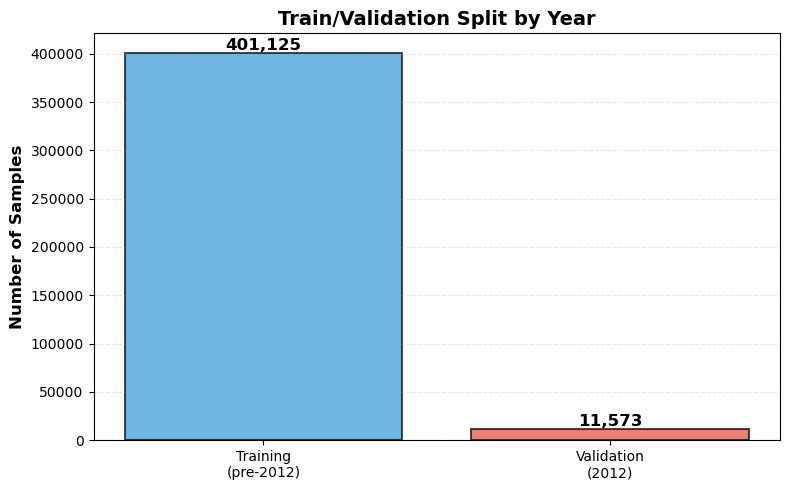


Train: 401,125 (97.2%)
Validation: 11,573 (2.8%)


In [82]:
# Visualize the train/validation split (only for vizualization purpose)
import matplotlib.pyplot as plt

# Count samples in each set
split_data = {
    'Training\n(pre-2012)': len(df_train),
    'Validation\n(2012)': len(df_val)
}

# Create bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(split_data.keys(), split_data.values(), color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=1.5)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Train/Validation Split by Year', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Print percentages
total = len(df_train) + len(df_val)
print(f'\nTrain: {len(df_train):,} ({100*len(df_train)/total:.1f}%)')
print(f'Validation: {len(df_val):,} ({100*len(df_val)/total:.1f}%)')

In [83]:
# Split data into X and y
X_train, y_train = df_train.drop("SalePrice", axis=1), df_train["SalePrice"]
X_valid, y_valid = df_val.drop("SalePrice", axis=1), df_val["SalePrice"]

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((401125, 102), (401125,), (11573, 102), (11573,))

In [84]:
y_train

0          9500.0
1         14000.0
2         50000.0
3         16000.0
4         22000.0
           ...   
401120    29000.0
401121    11000.0
401122    11000.0
401123    18000.0
401124    13500.0
Name: SalePrice, Length: 401125, dtype: float64

### Why Filling Before Splitting Is a Problem (Data Leakage)

**Think of it like this:** you are practicing for a test, but your practice notes accidentally include tomorrow’s answers.  
Your score looks great, but it is not a fair score.

1. **What went wrong**
You filled missing values on the full dataset first (past + future together), and only then split into train/validation.

2. **Why this is risky**
This leaks future information (validation year: 2012) into past training data.  
This is called **data leakage**: using future/test information during training prep.

3. **How it interferes with the model**
Your validation score becomes too optimistic (looks better than real-world performance).  
So the metric does not “**hold water**” (meaning: it is not reliable evidence).

4. **Correct fix (safe order)**
Split first by time, then preprocess with training-only statistics.

```python
# 1) Split first so past and future are separated
df_val = df_tmp[df_tmp.saleYear == 2012]          # future-like validation
df_train = df_tmp[df_tmp.saleYear != 2012]        # past-like training

# 2) Compute fill values from training only (no future leakage)
train_median = df_train["MachineHoursCurrentMeter"].median()  # training statistic

# 3) Fill training with training statistic
df_train["MachineHoursCurrentMeter"] = df_train["MachineHoursCurrentMeter"].fillna(train_median)  # safe fill

# 4) Fill validation with the SAME training statistic
df_val["MachineHoursCurrentMeter"] = df_val["MachineHoursCurrentMeter"].fillna(train_median)      # no future info used

### **Building an evaluation function**

In [85]:
# Create a evaluation fuction (the compitition uses RMSLE)
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score

def rmsle(y_test, y_preds):
    """
    Calculates the Root mean square log error
    between predictions and true labels.
    """
    return np.sqrt(mean_squared_log_error(y_test, y_preds))

# Create a function to evalaute model on few different labels
def show_scores(model):
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_valid)
    scores = {"Training MAE" : mean_absolute_error(y_train, train_preds),
              "Valid MAE" : mean_absolute_error(y_valid, val_preds),
              "Training RMSLE" : rmsle(y_train, train_preds),
              "Valid RMSLE" : rmsle(y_valid, val_preds),
              "Training R^2" : r2_score(y_train, train_preds),
              "Valid R^2" : r2_score(y_valid, val_preds)}
    return scores

## **Testing our model on subset (to tune the hyperparameters)**

In [86]:
# # This takes far to long... for experimenting

# %%time
# from sklearn.ensemble import RandomForestRegressor

# model = RandomForestRegressor(n_jobs=-1,
#                               random_state=42)

# model.fit(X_train, y_train)

In [87]:
len(X_train), len(X_valid)

(401125, 11573)

In [88]:
X_train.shape[0]

401125

In [89]:
from sklearn.ensemble import RandomForestRegressor

# Change the max_samples value
model = RandomForestRegressor(n_jobs=-1,
                              random_state=42,
                              max_samples=20000) # max_samples=20000,  # Train each tree on 20k random samples to speed training & reduce overfitting
# Each tree in the forest trains on only 20,000 random samples out of 401125

In reference to real life example:
- **Without `max_samples`:** Each student reads the entire 401k-page textbook

- **With `max_samples=20k`:** Each student reads only 20k pages

> `max_samples` picks samples randomly for each tree.

In [90]:
%%time

# Cutting down on the max number of samples each estimators can see improves training time
model.fit(X_train, y_train)

CPU times: total: 1min 42s
Wall time: 8.9 s


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [91]:
show_scores(model)

{'Training MAE': 5047.994491916485,
 'Valid MAE': 6754.1377611682365,
 'Training RMSLE': np.float64(0.23695842660674304),
 'Valid RMSLE': np.float64(0.27792674678471974),
 'Training R^2': 0.8833629837266057,
 'Valid R^2': 0.8501458046953285}

In [92]:
401125/20000

20.05625

In [93]:
# Calculate training speedup from max_samples
total_samples = len(X_train)
max_samples_param = 20000

speedup_ratio = total_samples / max_samples_param
print(f"Total training samples: {total_samples:,}")
print(f"Samples per tree (max_samples): {max_samples_param:,}")
print(f"Work reduction per estimator: {speedup_ratio:.1f}x")
print(f"\nIf each tree decision has ~log(n) splits:")
print(f"  - Without limit: log({total_samples:,}) ≈ {np.log2(total_samples):.1f} levels")
print(f"  - With max_samples: log({max_samples_param:,}) ≈ {np.log2(max_samples_param):.1f} levels")
print(f"  - Level reduction: {np.log2(total_samples)/np.log2(max_samples_param):.2f}x fewer levels to evaluate")

Total training samples: 401,125
Samples per tree (max_samples): 20,000
Work reduction per estimator: 20.1x

If each tree decision has ~log(n) splits:
  - Without limit: log(401,125) ≈ 18.6 levels
  - With max_samples: log(20,000) ≈ 14.3 levels
  - Level reduction: 1.30x fewer levels to evaluate


### **Hyperparameter tuning with RandomizedSearchCV**

In [94]:
model = RandomForestRegressor()
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [95]:
%%time

from sklearn.model_selection import RandomizedSearchCV

# Different RandomForestRegressor hyperparameters
rf_grid = {
    "n_estimators": np.arange(10, 100, 10),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2),
    "max_features": [0.5, 1, "sqrt", "log2"],
    "max_samples": [20000],
}

# Instantiate RandomizedSearchCV
rs_model = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=rf_grid,
    n_jobs=-1,
    n_iter=2,
    cv=5,
    verbose=True,
)

# Fit the RandomizedSearchCV model
rs_model.fit(X_train, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
CPU times: total: 1.5 s
Wall time: 10.1 s


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 3, ...], 'max_features': [0.5, 1, ...], 'max_samples': [20000], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), ...}"
,n_iter,2
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [96]:
# Find the best model Hyperparameter
rs_model.best_params_ # type: ignore

{'n_estimators': np.int64(10),
 'min_samples_split': np.int64(10),
 'min_samples_leaf': np.int64(1),
 'max_samples': 20000,
 'max_features': 'log2',
 'max_depth': 10}

In [97]:
# Evaluate the RandomizedSearchModel
show_scores(rs_model) # type: ignore

{'Training MAE': 9870.547255708088,
 'Valid MAE': 11348.800509538596,
 'Training RMSLE': np.float64(0.43327840115294186),
 'Valid RMSLE': np.float64(0.4494215253825108),
 'Training R^2': 0.6230672703578144,
 'Valid R^2': 0.62911182300095}

### **Train model with the best hyperparameter**

Note: These were found after 100 iterations of `RandomizedSearchCV` with `n_iter=100`

In [98]:
%%time

# Most ideal hyperparamter
ideal_model = RandomForestRegressor(n_estimators=90,
                                    min_samples_leaf=1,
                                    min_samples_split=14,
                                    max_features=0.5,
                                    n_jobs=-1,
                                    max_samples=None,
                                    random_state=42)

ideal_model.fit(X_train, y_train)

CPU times: total: 20min 45s
Wall time: 2min 8s


,n_estimators,90
,criterion,'squared_error'
,max_depth,None
,min_samples_split,14
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [99]:
# Scores for the model (trained on all data)
show_scores(ideal_model) # type: ignore

{'Training MAE': 2929.9215684333544,
 'Valid MAE': 5926.828732131215,
 'Training RMSLE': np.float64(0.14357234549234102),
 'Valid RMSLE': np.float64(0.24477262723855048),
 'Training R^2': 0.9596218418812977,
 'Valid R^2': 0.8829608391304741}

In [ ]:
# Scores on rs_model (only trained on ~10,000 examples)
show_scores(rs_model) # type: ignore

{'Training MAE': 9870.547255708088,
 'Valid MAE': 11348.800509538596,
 'Training RMSLE': np.float64(0.43327840115294186),
 'Valid RMSLE': np.float64(0.44942152538251073),
 'Training R^2': 0.6230672703578144,
 'Valid R^2': 0.62911182300095}

## **Make predictions on test data**

In [102]:
df_test = pd.read_csv("./dataset/Test.csv",
                      low_memory=False)
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelDescriptor,ProductSize,fiProductClassDesc,state,ProductGroup,ProductGroupDesc,Drive_System,Enclosure,Forks,Pad_Type,Ride_Control,Stick,Transmission,Turbocharged,Blade_Extension,Blade_Width,Enclosure_Type,Engine_Horsepower,Hydraulics,Pushblock,Ripper,Scarifier,Tip_Control,Tire_Size,Coupler,Coupler_System,Grouser_Tracks,Hydraulics_Flow,Track_Type,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1227829,1006309,3168,121,3,1999,3688.0,Low,5/3/2012 0:00,580G,580,G,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Wyoming,BL,Backhoe Loaders,Two Wheel Drive,OROPS,Yes,None or Unspecified,No,Standard,Standard,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1227844,1022817,7271,121,3,1000,28555.0,High,5/10/2012 0:00,936,936,NaN,NaN,NaN,Medium,Wheel Loader - 135.0 to 150.0 Horsepower,Virginia,WL,Wheel Loader,NaN,EROPS,Yes,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,20.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1227847,1031560,22805,121,3,2004,6038.0,Medium,5/10/2012 0:00,EC210BLC,EC210,B,NaN,LC,Large / Medium,"Hydraulic Excavator, Track - 21.0 to 24.0 Metr...",New Jersey,TEX,Track Excavators,NaN,EROPS w AC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,NaN,Steel,None or Unspecified,"9' 6""",Manual,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
3,1227848,56204,1269,121,3,2006,8940.0,High,5/10/2012 0:00,330CL,330,C,NaN,L,Large / Medium,"Hydraulic Excavator, Track - 33.0 to 40.0 Metr...",New Jersey,TEX,Track Excavators,NaN,EROPS w AC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,NaN,Steel,None or Unspecified,None or Unspecified,Manual,Yes,Triple,NaN,NaN,NaN,NaN,NaN
4,1227863,1053887,22312,121,3,2005,2286.0,Low,5/10/2012 0:00,650K,650,K,NaN,NaN,NaN,"Track Type Tractor, Dozer - 20.0 to 75.0 Horse...",Florida,TTT,Track Type Tractors,NaN,OROPS,NaN,NaN,NaN,NaN,Hydrostatic,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN
